## **HW4 Solution: Feature Engineering and Logistic Regression**

### **TODO: Martin Jesus Colmenero Jr**

**Attention:** This is an individual assignment.

# **Overview**
In this assignment, you will work with the Indian Liver Patient Dataset (ILPD) from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/). You will perform feature engineering, data preprocessing, dimensionality reduction, and logistic regression to predict whether a patient has liver disease.

In [87]:
# Optional diplay all columns to be able to see all the columns (features)
import pandas as pd
pd.set_option('display.max_columns', None)

## **Description of the Dataset**


* The ILPD comprises 583 patient records with 10 biochemical/demographic features and a target feature that are listed below:

The dataset has the following columns:

- `Age` (Integer): Patient's age.
- `Gender` (Categorical: Male/Female).
- `TB` (Total Bilirubin, Continuous).
- `DB` (Direct Bilirubin, Continuous).
- `Alkphos` (Alkaline Phosphotase, Integer).
- `Sgpt` (Alamine Aminotransferase, Integer).
- `Sgot` (Aspartate Aminotransferase, Integer).
- `TP` (Total Proteins, Continuous).
- `ALB` (Albumin, Continuous).
- `A/G Ratio` (Albumin and Globulin Ratio, Continuous).
- `Selector` (Binary: 1 = Liver patient, 2 = Non-liver patient)

### **Question 1: Import libraries, Load the Dataset, and Create a Header**

* You will notice that the CSV file is missing the header with column names. The header will need to be created.
* Load the dataset, assign correct column names, and display the first five rows.
* Convert `Target` (previously referred as "Selector") into a binary classification where 1 = Liver Patient and 0 = Non-Liver Patient.

In [88]:
# write your code here
# Define column names and cerate a dataframe
# Convert 'Target' to binary classification (1 = Liver Patient, 0 = Non-Liver Patient)
# display the first few row to observe the data

column_names = ['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio', 'Target']
df = pd.read_csv('ILPD.csv')
df.columns = column_names
df['Target'] = df['Target'].replace({1:1,2:0})
df.head(5)


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
0,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
1,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
2,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
3,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
4,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.30,1


### **Question 2: Identify columns with missing data (if any) and then determine an appropriate strategy for each**

* Identify missing values in each column.
Fill missing values:
  - Median imputation for numerical columns.
  - Mode imputation for categorical columns.

In [89]:
# Write your code here
df.isna().sum()

,0
Age,0
Gender,0
TB,0
DB,0
Alkphos,0
Sgpt,0
Sgot,0
TP,0
ALB,0
A/G Ratio,4


In [90]:
# Impute missing values make sure you avoid the chain statement warning when inplace=True is used.
df.fillna({'A/G Ratio':df['A/G Ratio'].median()}, inplace=True)


# Verify that missing values are handled. Hint use `assert` which is a keyword (statement)
# used for debugging and validation. The assert statement checks if a given condition is True.
# If the condition is False, Python raises an AssertionError with an optional error message.

df.isnull().sum()

,0
Age,0
Gender,0
TB,0
DB,0
Alkphos,0
Sgpt,0
Sgot,0
TP,0
ALB,0
A/G Ratio,0


### **Question 3: One-hot Encoding for Categorical Variables**

* Convert "Gender" into a binary feature (0 = Female, 1 = Male).

In [91]:
# Write your code here
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df_encoded['Gender_Male'] = df_encoded['Gender_Male'].replace({True:1,False:0})
df_encoded.head()

<ipython-input-91-c443f6f89667>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded['Gender_Male'] = df_encoded['Gender_Male'].replace({True:1,False:0})


,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,Gender_Male
0,62,10.9,5.5,699,64,100,7.5,3.2,0.74,1,1
1,62,7.3,4.1,490,60,68,7.0,3.3,0.89,1,1
2,58,1.0,0.4,182,14,20,6.8,3.4,1.00,1,1
3,72,3.9,2.0,195,27,59,7.3,2.4,0.40,1,1
4,46,1.8,0.7,208,19,14,7.6,4.4,1.30,1,1


### **Question 4: Feature Extraction**

* Engineer new features using existing ones. Create:

  - Bilirubin Ratio (DB / TB).
  - ALT/AST Ratio (Sgpt / Sgot).

In [92]:
# Write your code here
# Create new engineered features
df_encoded['Bilirubin Ratio'] = df_encoded['DB'] / df_encoded['TB']
df_encoded['ALT/AST Ratio'] = df_encoded['Sgpt'] / df_encoded['Sgot']

### **Question 5: Standardization**

* Scale all numerical features to have mean = 0 and standard deviation = 1.


In [93]:
# Write your code here
# Select numerical columns (excluding categorical and target variable)
# Apply Standard Scaling
# Display first few rows after scaling
from sklearn.preprocessing import StandardScaler

numerical_columns = df_encoded.columns.tolist()
numerical_columns.remove('Gender_Male')
numerical_columns.remove('Target')
numerical_columns.remove('Age')

scaler = StandardScaler()
df_encoded[numerical_columns] = scaler.fit_transform(df_encoded[numerical_columns])
df_encoded.head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,Gender_Male,Bilirubin Ratio,ALT/AST Ratio
0,62,1.223586,1.428648,1.680715,-0.092140,-0.034853,0.937332,0.073438,-0.650251,1,1,0.463941,-0.472172
1,62,0.643743,0.930056,0.820279,-0.114045,-0.145620,0.476661,0.199146,-0.179274,1,1,0.656711,-0.093879
2,58,-0.370981,-0.387651,-0.447733,-0.365961,-0.311772,0.292392,0.324855,0.166110,1,1,0.110585,-0.378517
3,72,0.096115,0.182168,-0.394213,-0.294768,-0.176774,0.753063,-0.932229,-1.717800,1,1,0.491758,-0.756841
4,46,-0.242127,-0.280810,-0.340693,-0.338579,-0.332540,1.029466,1.581939,1.108065,1,1,0.073045,0.647230


### **Question 6: Engineering Ordinal Features**



**Define the Age Groups:**

For this question, you need to categorize Age into three ordinal groups and assign an appropriate numeric value to each group.


* Young: Age below 30
* Middle-Aged: Age between 30 and 50 (inclusive)
* Senior: Age above 50


Ensure that all Age values are assigned to a group by dynamically determining the bin ranges. Convert the categorical `Age_Group` feature into an ordinal variable `Age_Ordinal`, mapping:

* Young → 1
* Middle-Aged → 2
* Senior → 3

Handle any missing values that might arise during this transformation.

**Hints to Approach the Problem:**

* Check all Age values are categorized: If some values fall outside the predefined bins, adjust the bin ranges dynamically to prevent missing values.

* Be mindful of edge cases: If all values in the Age column are identical, traditional binning might fail. Think about how to handle this scenario.
* Check to make sure that bins are strictly increasing to avoid errors like
`ValueError: bins must increase monotonically.`

* Handle missing values: After mapping ordinal categories, some entries may still have `NaN` values. Use an appropriate imputation strategy (e.g., replacing with the most common category).

**Expected Output Example:**

Your final DataFrame should include three new columns:

| Age | Age_Group     | Age_Ordinal |
|-----|-------------|------------|
| 25  | Young       | 1          |
| 40  | Middle-Aged | 2          |
| 55  | Senior         | 3          |

Make sure to check the distribution of the new categorical feature (`Age_Group`) and the final `Age_Ordinal` values to verify correctness.

In [94]:
# Get min and max age values
age_min = df['Age'].min()
age_max = df['Age'].max()

# Ensure distinct bin edges by forcing strictly increasing values
age_bins = sorted(set([age_min, 30, 50, age_max]))  # Remove duplicates and sort
age_labels = ['Young', 'Middle-Aged', 'Senior']

# Ensure at least three unique bin edges
if len(age_bins) < 3:
    age_bins = [age_min, (age_min + age_max) / 2, age_max]  # Fallback bins
    age_labels = ['Young', 'Senior']

# Apply binning. To categorize Age into meaningful groups, you should use the pd.cut() method. Check out the documentation for more info on this pandas method.
# This function allows you to divide continuous numerical data into discrete bins based on specified boundaries.
# The pd.cut() function segments the Age column into predefined bins (age_bins) and assigns corresponding labels (age_labels).
# The include_lowest=True parameter ensures that the lowest value in the dataset is included in the first bin.

# Map ordinal categories
# Display first few rows
df_encoded['Age_Group'] = pd.cut(df_encoded['Age'], bins=age_bins, labels=age_labels, include_lowest=True)
df_encoded['Age_Ordinal'] = df_encoded['Age_Group'].map({'Young': 1, 'Middle-Aged': 2, 'Senior': 3})
df_encoded.fillna({'Age_Ordinal':df_encoded['Age_Ordinal'].mode()}, inplace=True)
df_encoded.head()



,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,Gender_Male,Bilirubin Ratio,ALT/AST Ratio,Age_Group,Age_Ordinal
0,62,1.223586,1.428648,1.680715,-0.092140,-0.034853,0.937332,0.073438,-0.650251,1,1,0.463941,-0.472172,Senior,3
1,62,0.643743,0.930056,0.820279,-0.114045,-0.145620,0.476661,0.199146,-0.179274,1,1,0.656711,-0.093879,Senior,3
2,58,-0.370981,-0.387651,-0.447733,-0.365961,-0.311772,0.292392,0.324855,0.166110,1,1,0.110585,-0.378517,Senior,3
3,72,0.096115,0.182168,-0.394213,-0.294768,-0.176774,0.753063,-0.932229,-1.717800,1,1,0.491758,-0.756841,Senior,3
4,46,-0.242127,-0.280810,-0.340693,-0.338579,-0.332540,1.029466,1.581939,1.108065,1,1,0.073045,0.647230,Middle-Aged,2


### **Question 7: Dimensionality Reduction**

* Apply PCA and retain components that explain at least 95% of variance.
* Remember, PCA (Principal Component Analysis) does not work on categorical columns because PCA is a linear transformation technique that relies on numerical data and calculates variance and covariance among features. This means you will need to drop them first.

In [95]:
# Write your code here
from sklearn.decomposition import PCA

x_pca = df_encoded.drop(columns=['Target', 'Age_Group', 'Age_Ordinal', 'Gender_Male'])

pca = PCA(n_components=0.95)

x_pca_tranformed = pca.fit_transform(x_pca)


# Output the number of principal components retained

num_components_retained = pca.n_components_

print(f'Number of principal components retained: {num_components_retained}')

Number of principal components retained: 1


## **Question 8: Logistic Regression Model**

* Train a logistic regression model using the processed dataset.
* Evaluate its performance with its accuracy score, confusion matrix and a classification report.

In [108]:
# write your code here
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = x_pca_tranformed
y = df_encoded['Target']

logit_model = LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, train_size=0.8)
logit_model.fit(X_train, y_train)

y_pred = logit_model.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print(f'coefficient estimate: {logit_model.coef_}')

Accuracy: 0.7435897435897436
Confusion Matrix:
 [[ 0 30]
 [ 0 87]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.74      1.00      0.85        87

    accuracy                           0.74       117
   macro avg       0.37      0.50      0.43       117
weighted avg       0.55      0.74      0.63       117

coefficient estimate: [[0.01779122]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Question 9: Visualization**
* Plot the distribution of Total Bilirubin (TB) for liver and non-liver patients.
* Make sure your plot has the appropriate title and x and y labels.
* You can use either `sns.histplot` or matplotlib for this question.


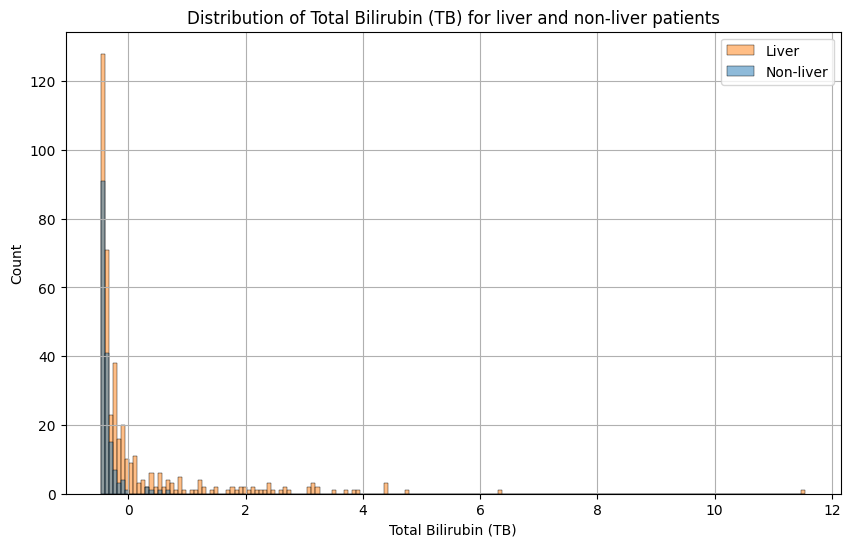

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
# write your code here

plt.figure(figsize=(10,6))
sns.histplot(data=df_encoded, x='TB', hue='Target')
plt.title('Distribution of Total Bilirubin (TB) for liver and non-liver patients')
plt.xlabel('Total Bilirubin (TB)')
plt.ylabel('Count')
plt.legend(['Liver', 'Non-liver'])
plt.grid()
plt.show()

## **Question 11 (20 pts): Interpretation Questions**

**READ THE INSTRUCTIONS BELOW CAREFULLY**

* For the questions below, provide a **detailed and well-reasoned analysis based on your observations. Your responses should be specific, data-driven, and insightful**, similar to what would be expected in a professional data science setting. Avoid vague or generic answers—support your interpretation with evidence from the dataset, model outputs, or domain knowledge where applicable. **Each response should be at least** 2-3 well-structured sentences that demonstrate a clear understanding of the results.

**A.   Model Performance Analysis:**

  - Based on the confusion matrix and classification report, how well does the logistic regression model perform?
  - Which type of misclassification is more concerning in the context of liver disease (false positives or false negatives)?

**Write your answer for A here: Based on the confusion matrix and classification report, the logistic model is able to accurately predict liver and non-liver patients 74% of the time. In the context of of liver disease, false positives are more concerning since the confusion matrix shows that the model made 30 false positve predictions and 0 false negative predictions.**

**B. Feature Importance:**

  - Based on the logistic regression coefficients, which features seem to have the strongest impact on the predictions?
  - Are these findings aligned with medical knowledge about liver disease?

**Write your answer for B here: Since only on component was retained during PCA, Alamine Aminotransferase (SGPT) was the strongest predictor of liver disease based on the logistic model with a coefficient estimate of 0.017. According to Google, this does align with medical knowledge where high levels of SGPT can lead to liver failure.**

**C. PCA Results Discussion:**

  - How many components were retained after PCA?
  - Does reducing dimensionality improve model performance, or might it remove important predictive information?

**Write your answer for C here: After PCA analysis, only 1 component was retained. Reducing dimensionality does imporve model performance since we only considering the variables with the highest predictive power from our dataset. Based on our PCA anylsis, only SGPT caputures most of the variation in the dataset.**

**D. Feature Engineering Impact:** Consider the engineered features (e.g., the ALT/AST ratio, Bilirubin Ratio, and binned Age feature). How might these transformations enhance the model's predictive power? Are there potential downsides or biases introduced by these transformations?



**Write your written answer for D here: By doing these tranformations, we were adding interadtion variables and more dummy variables in our regression model which helps control for more factors that effect liver disease. One issue I see by adding these variables is having high multicolierity mainly with the binned Age feature since we essentially three variables that are controlling for Age ('Age', 'Grouped_Age', 'Age_Orbital')**

**E. Visualization Interpretation:**

  - What does the distribution of Total Bilirubin suggest about liver disease status?
  - Would you expect this feature to be a strong predictor? Why?

**Write your written answer for E here: The distribution suggests that non-liver patients have a higher level of Total Bilirubin than liver patients. According to Google, highe level of bilirubin are attributed to liver cancer while low levels of bilirubin are attributed to liver disease. Based on that information, I would expect total bilirubin to not be a strong predictor of liver disease.**